In [1]:
#downloading the dataset (plantVillage)
import kagglehub
path= kagglehub.dataset_download("emmarex/plantdisease")

Using Colab cache for faster access to the 'plantdisease' dataset.


In [2]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/plantdisease
['PlantVillage', 'plantvillage']


In [3]:
import os

print("PlantVillage:")
print(os.listdir("/kaggle/input/plantdisease/PlantVillage")[:10])

print("\nplantvillage:")
print(os.listdir("/kaggle/input/plantdisease/plantvillage")[:10])

PlantVillage:
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot']

plantvillage:
['PlantVillage']


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import keras
from tensorflow.keras.models import Sequential

In [5]:
import tensorflow as tf

#assigning variable values
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42# for randomness

# 80% Training
base_dir='/kaggle/input/plantdisease/PlantVillage'
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 20% Testing
test_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",   # Using the remaining 20% as test
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


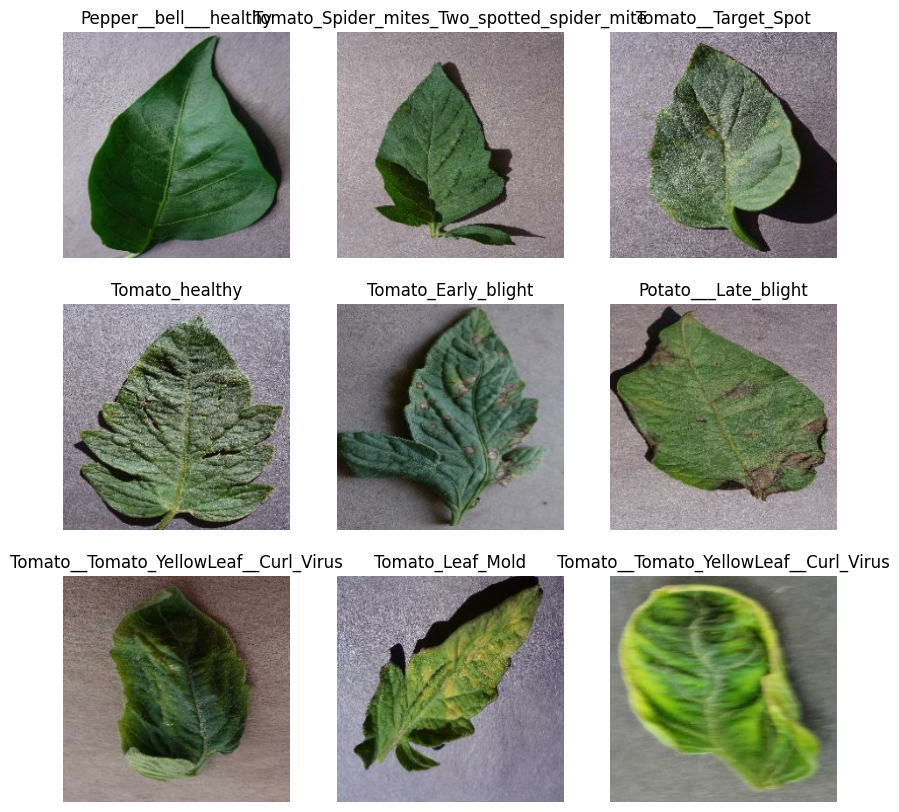

In [6]:

#using matplotlib to visualize some images
import matplotlib.pyplot as plt
class_names = train_ds.class_names
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

Text(0.5, 1.0, 'Tomato__Tomato_YellowLeaf__Curl_Virus')

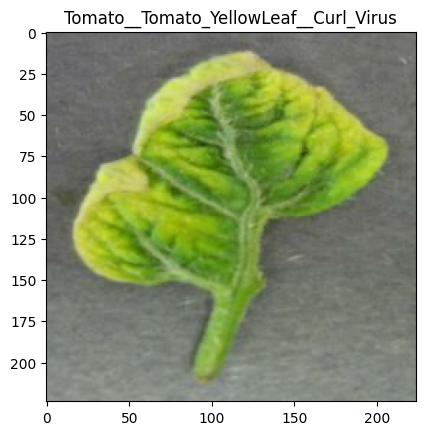

In [7]:
plt.imshow(images[31].numpy().astype("uint8"))
plt.title(class_names[labels[31]])

In [8]:
#checking pizel value of images
for images, labels in train_ds.take(1):
    print(images[0].numpy().max())

248.31512


In [9]:
#using cnn model with 3 convolution layer
cnn=keras.Sequential([
    keras.layers.Rescaling(1./255),#divides every pixel value by 255 for easy computation
    keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(224,224,3)),#learn features
    keras.layers.MaxPooling2D(pool_size=(2,2)),#reduce image size
    keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(15,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [11]:
cnn.fit(train_ds,epochs=20)

Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 57s 87ms/step - accuracy: 0.4950 - loss: 1.5728
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 57s 55ms/step - accuracy: 0.7167 - loss: 0.8561
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 47s 68ms/step - accuracy: 0.7798 - loss: 0.6588
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.8297 - loss: 0.5171
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.8640 - loss: 0.4026
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.8829 - loss: 0.3429
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.8967 - loss: 0.2999
Epoch 8/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9184 - loss: 0.2410
Epoch 9/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9212 - loss: 0.2241
Epoch 10/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9284 - loss: 0.2048
Epoch 11/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9374 - loss: 0.1866
Epoch 12/20
516/516 ━━━━━━━━━━

In [12]:
cnn.evaluate(test_ds)#testing accuracy

129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.9089 - loss: 0.3526


[0.35257887840270996, 0.9088926315307617]

In [25]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy :", accuracy)
print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 0.9088926581051612
Accuracy : 90.89%


In [27]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

Precision : 0.9117


In [28]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Recall : {recall:.4f}")

Recall : 0.9089


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


ValueError: num must be an integer with 1 <= num <= 9, not 10

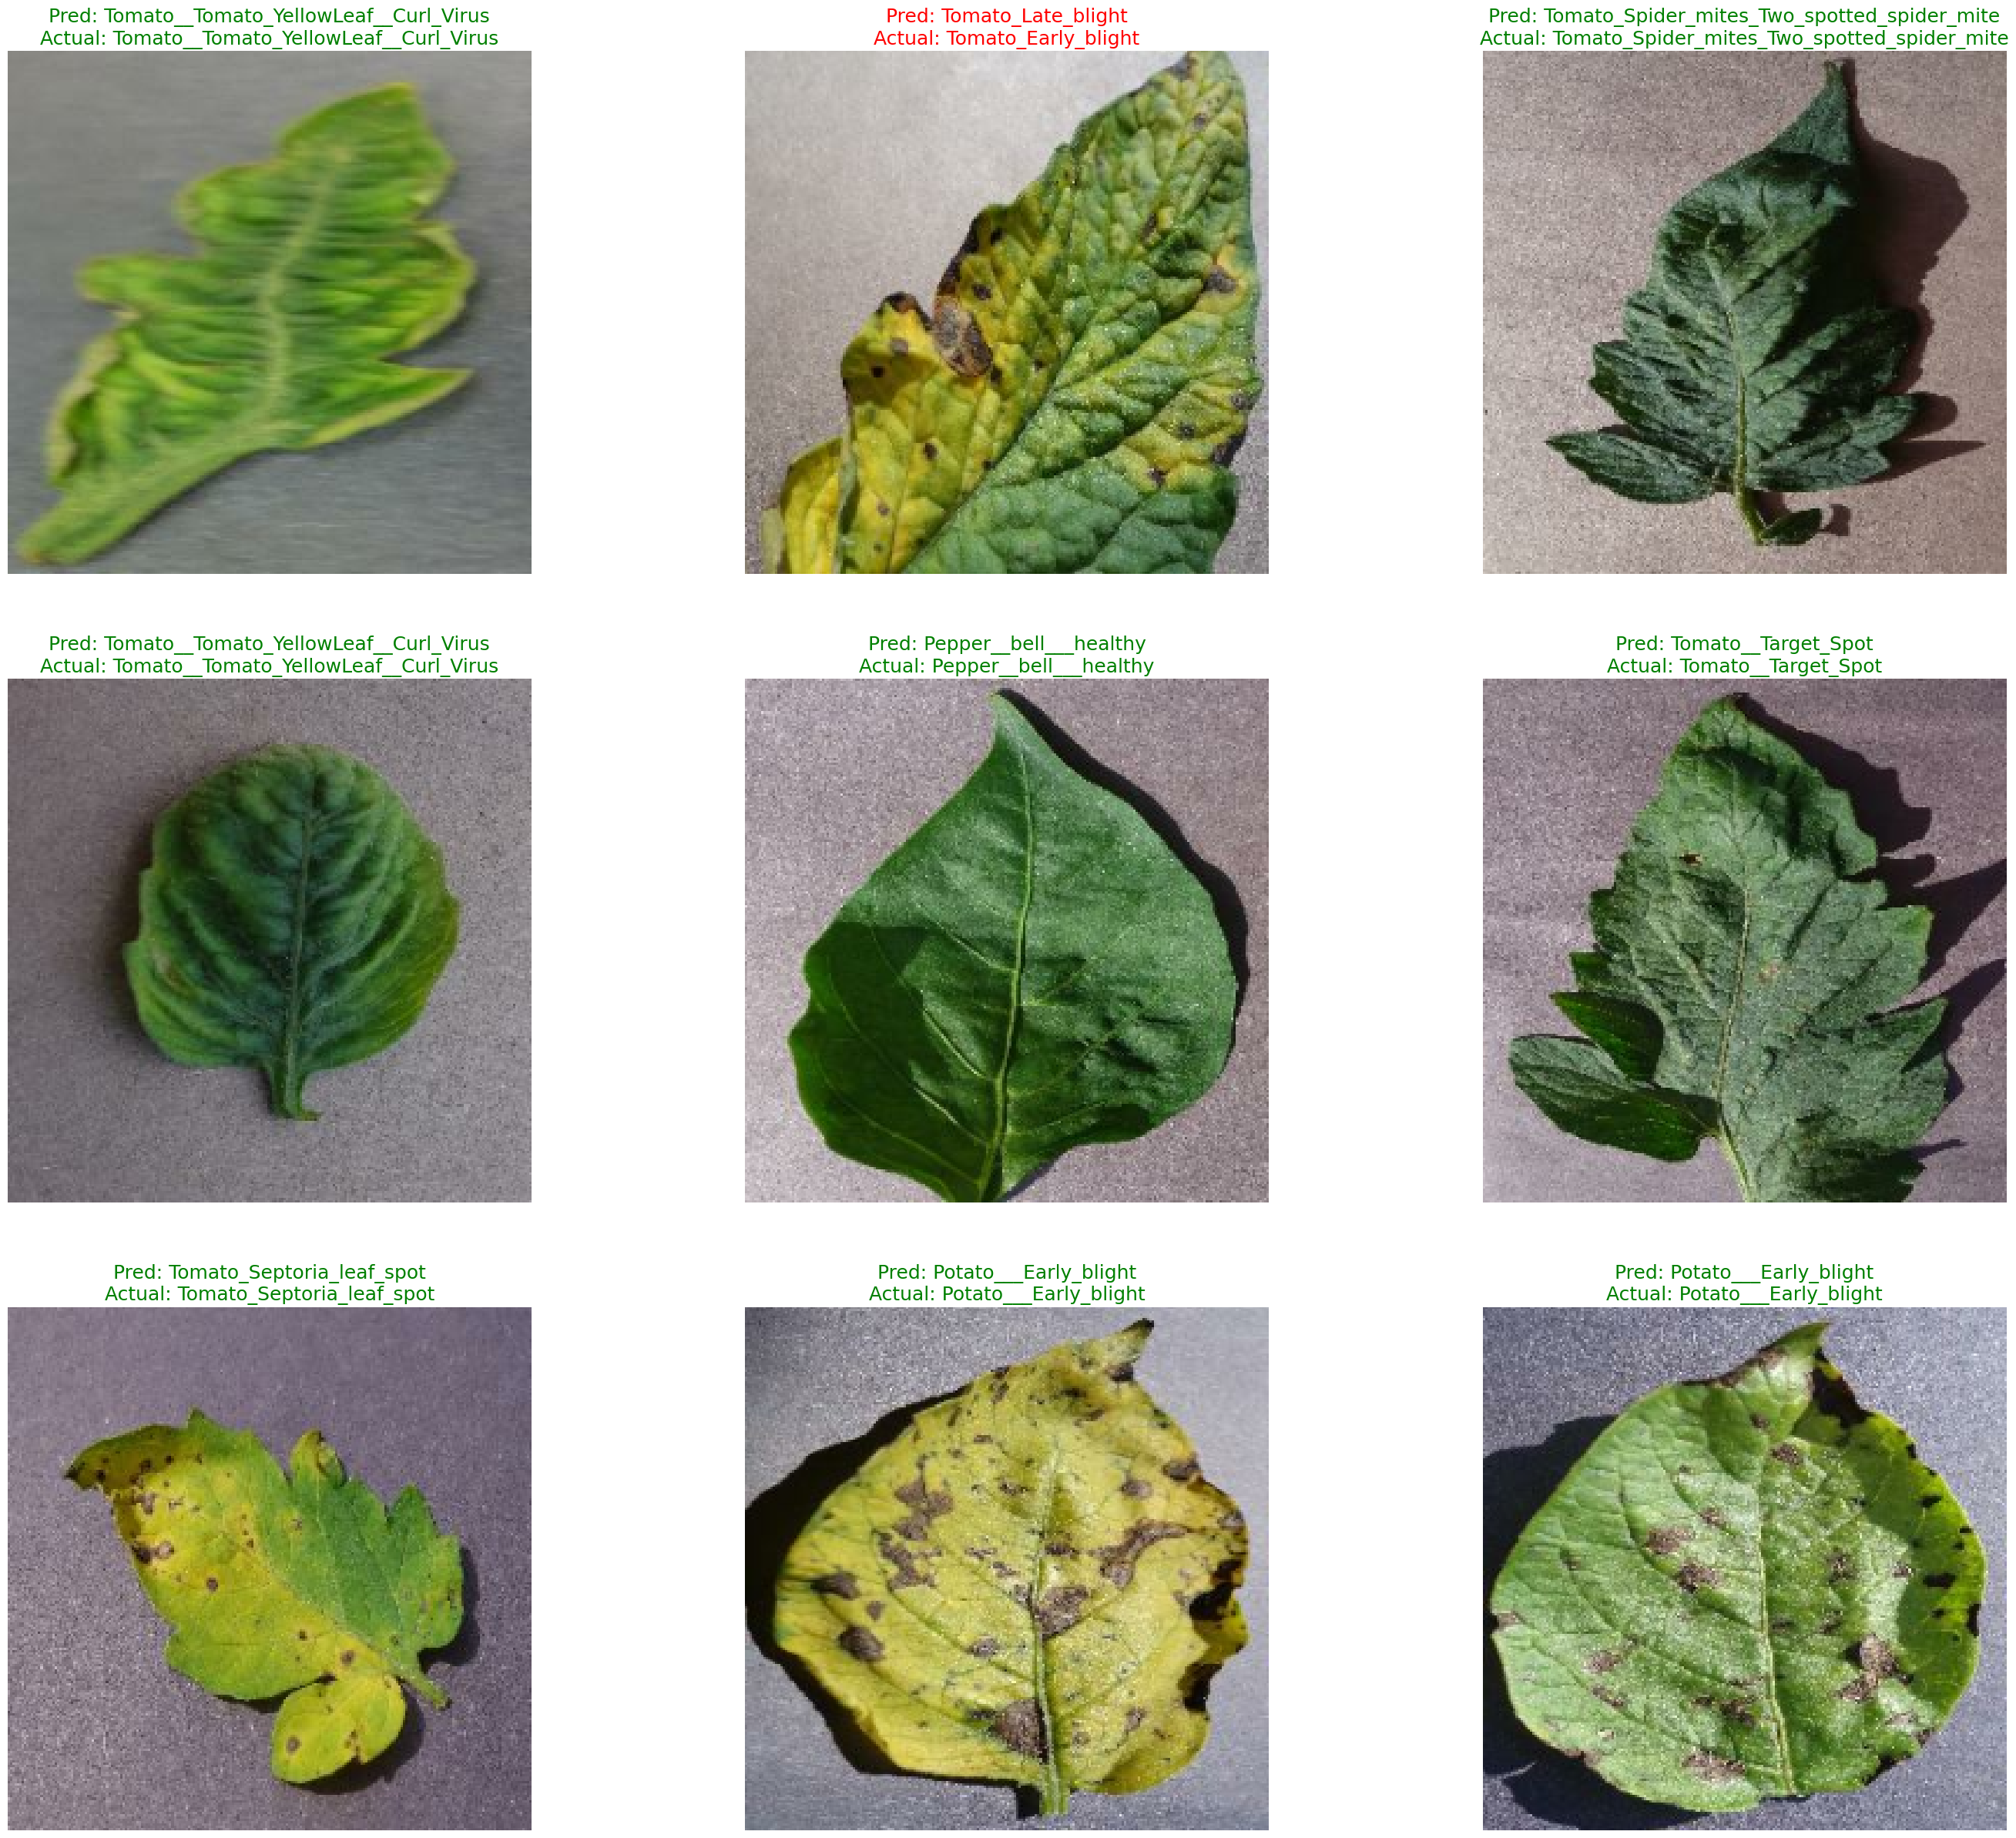

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the test dataset
for images, labels in test_ds.take(1):

    # Predict
    predictions = cnn.predict(images)

    plt.figure(figsize=(35, 30))

    for i in range(10):
        plt.subplot(3, 3, i + 1)

        # Display image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Predicted class
        predicted_label = class_names[np.argmax(predictions[i])]

        # Actual class
        actual_label = class_names[labels[i]]

        # Green if correct, Red if incorrect
        color = "green" if predicted_label == actual_label else "red"

        plt.title(
            f"Pred: {predicted_label}\nActual: {actual_label}",
            color=color,
            fontsize=18
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()